# Fire Radiative Power (FRP) Prediction Using Ensemble and Deep Learning Models with Explainable AI Integration

In [1]:
!pip install pytorch-tabnet shap xgboost

In [2]:
# importing the necessary libs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
from pytorch_tabnet.tab_model import TabNetRegressor
from xgboost import XGBRegressor
import torch

## GPU check

In [3]:
# Confirm PyTorch can see the GPU before running TabNet.
# If this prints False, reinstall torch with a CUDA build that matches
# your driver -- e.g. pip install torch --index-url https://download.pytorch.org/whl/cu121
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: NVIDIA GeForce RTX 3050 Laptop GPU


## Data loading, cleaning, and splitting

In [4]:
def load_data(file_path):
    data = pd.read_csv(file_path)
    print(f"Loaded {data.shape[0]} rows, {data.shape[1]} columns")
    return data

def clean_data(data):
    # l/n/h = low/nominal/high confidence -- ordinal, so integer encoding fits
    confidence_mapping = {'l': 1, 'n': 2, 'h': 3}
    daynight_mapping = {'D': 1, 'N': 2}
    data = data.copy()
    data['confidence'] = data['confidence'].map(confidence_mapping)
    data['daynight'] = data['daynight'].map(daynight_mapping)
    data = data.dropna(subset=['frp', 'confidence', 'daynight'])
    return data

FEATURES = ['latitude', 'longitude', 'brightness', 'bright_t31', 'confidence', 'daynight']
TARGET = 'frp'

def prepare_data(file_path, test_size=0.2, random_state=42):
    data = load_data(file_path)
    data = clean_data(data)

    X = data[FEATURES].copy()
    y = data[[TARGET]].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # fit the target transformer on the training set only, then apply it to both
    transformer = PowerTransformer(method='yeo-johnson')
    y_train = pd.Series(
        transformer.fit_transform(y_train).ravel(), index=y_train.index, name=TARGET
    )
    y_test = pd.Series(
        transformer.transform(y_test).ravel(), index=y_test.index, name=TARGET
    )

    # fit the feature scaler on the training set only, then apply it to both
    scaler = MinMaxScaler()
    X_train[FEATURES] = scaler.fit_transform(X_train[FEATURES])
    X_test[FEATURES] = scaler.transform(X_test[FEATURES])

    return X_train, X_test, y_train, y_test, scaler, transformer

# loading and splitting the dataset
file_path = 'fire_nrt_J2V-C2_538155(data1).csv'
X_train, X_test, y_train, y_test, scaler, transformer = prepare_data(file_path)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loaded 103070 rows, 14 columns
Train: (82456, 6), Test: (20614, 6)


In [5]:
import joblib
import contextlib
from tqdm.auto import tqdm

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument."""

    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=1)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback

    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

## Random Forest

In [7]:
# Random Forest with hyperparameter tuning using RandomizedSearchCV
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, 20, 30],   # capped instead of allowing None (unbounded)
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]                 # bootstrap=False + no depth cap is what blows up memory
}

rf = RandomForestRegressor(random_state=42)
n_iter = 40
cv_folds = 5
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=n_iter,
    scoring='neg_mean_squared_error',
    cv=cv_folds,
    n_jobs=4,           # fewer parallel workers -> lower peak memory
    pre_dispatch='2*n_jobs',
    random_state=42,
    verbose=3
)
total_fits = n_iter * cv_folds
with tqdm_joblib(tqdm(total=total_fits, desc="RandomizedSearch Progress")) as progress_bar:
    rf_search.fit(X_train, y_train)

y_pred_rf = rf_search.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
print("Best params:", rf_search.best_params_)
print(rf_r2, rf_mse, rf_mae)

RandomizedSearch Progress:   0%|          | 0/200 [00:00<?, ?it/s]

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': True}
0.7216096767164886 0.27743019954817844 0.3972477257051835


## TabNet

In [8]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from tqdm.auto import tqdm
from pytorch_tabnet.tab_model import TabNetRegressor

# 1) Convert data to numpy
X_train_tab = X_train.to_numpy().astype(np.float32)
y_train_tab = y_train.to_numpy().reshape(-1, 1).astype(np.float32)
X_test_tab = X_test.to_numpy().astype(np.float32)

# 2) Small parameter search space
tabnet_params = [
    {'n_d': 8,  'n_a': 8,  'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 1e-4},
    {'n_d': 16, 'n_a': 16, 'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 1e-4},
    {'n_d': 8,  'n_a': 8,  'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 1e-3},
    {'n_d': 16, 'n_a': 8,  'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 1e-4},
]

# 3) K-Fold cross-validation strategy
n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 4) Track the best score/params during the search; only fit on the full
# training set once, after the search is done, instead of re-fitting every
# time a new best is found
best_params = None
best_score = -np.inf

total_fits = len(tabnet_params) * n_splits
with tqdm(total=total_fits, desc="TabNet search (config x fold)") as pbar:
    for params in tabnet_params:
        fold_scores = []

        for train_idx, val_idx in kf.split(X_train_tab):
            X_tr, X_val = X_train_tab[train_idx], X_train_tab[val_idx]
            y_tr, y_val = y_train_tab[train_idx], y_train_tab[val_idx]

            model = TabNetRegressor(**params, verbose=0, seed=42, device_name='cuda')
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                max_epochs=50,
                patience=5,
                batch_size=512,
                virtual_batch_size=128,
                num_workers=0
            )

            val_preds = model.predict(X_val).squeeze()
            fold_scores.append(r2_score(y_val, val_preds))
            pbar.update(1)

        avg_score = np.mean(fold_scores)
        print(f"Params: {params} | CV Average R2: {avg_score:.4f}")

        if avg_score > best_score:
            best_score = avg_score
            best_params = params

# 5) Fit the final model once, on the full training set, using the best params found
print("\nBest params:", best_params, "| CV Average R2:", best_score)
best_model = TabNetRegressor(**best_params, verbose=0, seed=42, device_name='cuda')
best_model.fit(
    X_train_tab, y_train_tab,
    max_epochs=50,
    patience=5,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=0
)

# 6) Evaluate the final best model on the test set
y_pred_test = best_model.predict(X_test_tab).squeeze()
test_r2 = r2_score(y_test, y_pred_test)

print("\n===== Final Results =====")
print("Best TabNet params:", best_params, "| Test R2:", test_r2)

TabNet search (config x fold):   0%|          | 0/12 [00:00<?, ?it/s]


Early stopping occurred at epoch 20 with best_epoch = 15 and best_val_0_mse = 0.3403399884700775


c:\Users\asus\anaconda3\envs\myenv\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 24 with best_epoch = 19 and best_val_0_mse = 0.3326199948787689


c:\Users\asus\anaconda3\envs\myenv\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


...


Early stopping occurred at epoch 18 with best_epoch = 13 and best_val_0_mse = 0.34398001432418823


c:\Users\asus\anaconda3\envs\myenv\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Params: {'n_d': 16, 'n_a': 8, 'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 0.0001} | CV Average R2: 0.6627

Best params: {'n_d': 16, 'n_a': 16, 'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 0.0001} | CV Average R2: 0.6636728644371033


c:\Users\asus\anaconda3\envs\myenv\lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)



===== Final Results =====
Best TabNet params: {'n_d': 16, 'n_a': 16, 'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 0.0001} | Test R2: 0.6678578928405637


## XGBoost

In [9]:
# XGBoost with hyperparameter tuning using RandomizedSearchCV
param_dist_xgb = {
    'n_estimators': [200, 300, 400, 600],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_model = XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist', device='cuda')
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
xgb_search.fit(X_train, y_train)

y_pred_xgb = xgb_search.predict(X_test)
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
print("Best XGB params:", xgb_search.best_params_)
print(xgb_r2, xgb_mse, xgb_mae)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB params: {'subsample': 0.85, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
0.7262382960675413 0.2728175435655658 0.3931922672692455


c:\Users\asus\anaconda3\envs\myenv\lib\site-packages\xgboost\core.py:729: UserWarning: [14:32:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


## Model comparison

In [10]:
# Evaluation of the models using MAE, MSE and R2 scores
results_df = pd.DataFrame({
    'Model': ['RF', 'TabNet', 'XGBoost'],
    'MAE': [rf_mae, mean_absolute_error(y_test, y_pred_test), xgb_mae],
    'MSE': [rf_mse, mean_squared_error(y_test, y_pred_test), xgb_mse],
    'R\u00b2': [rf_r2, test_r2, xgb_r2]
})

print("Model Evaluation Results:")
print(results_df.to_string(index=False, float_format='%.4f'))

Model Evaluation Results:
  Model    MAE    MSE     R²
     RF 0.3972 0.2774 0.7216
 TabNet 0.4390 0.3310 0.6679
XGBoost 0.3932 0.2728 0.7262


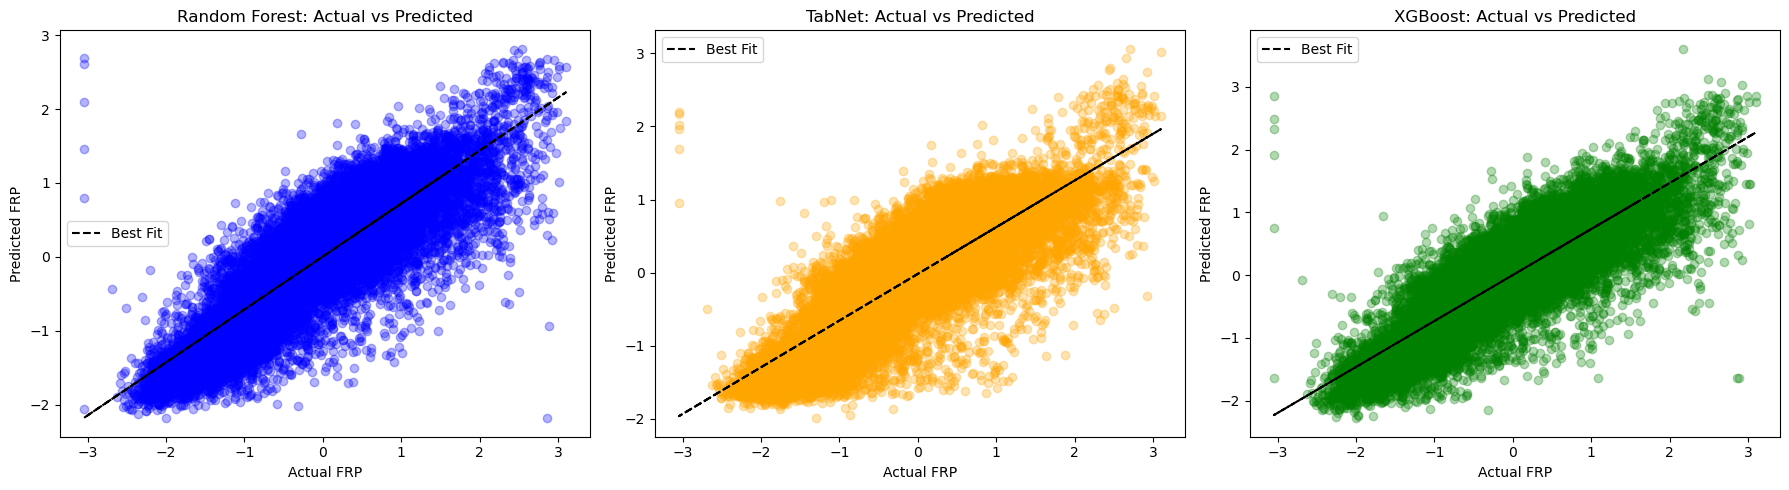

In [11]:
# Plotting the predictions of the models in comparison
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
m_rf, b_rf = np.polyfit(y_test, y_pred_rf, 1)
plt.plot(y_test, m_rf * y_test + b_rf, color='black', linestyle='--', label='Best Fit')
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual FRP")
plt.ylabel("Predicted FRP")
plt.legend()

plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_test, alpha=0.3, color='orange')
m_tab, b_tab = np.polyfit(y_test, y_pred_test, 1)
plt.plot(y_test, m_tab * y_test + b_tab, color='black', linestyle='--', label='Best Fit')
plt.legend()
plt.title("TabNet: Actual vs Predicted")
plt.xlabel("Actual FRP")
plt.ylabel("Predicted FRP")

plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='green')
m_xgb, b_xgb = np.polyfit(y_test, y_pred_xgb, 1)
plt.plot(y_test, m_xgb * y_test + b_xgb, color='black', linestyle='--', label='Best Fit')
plt.legend()
plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Actual FRP")
plt.ylabel("Predicted FRP")

plt.tight_layout()
plt.show()

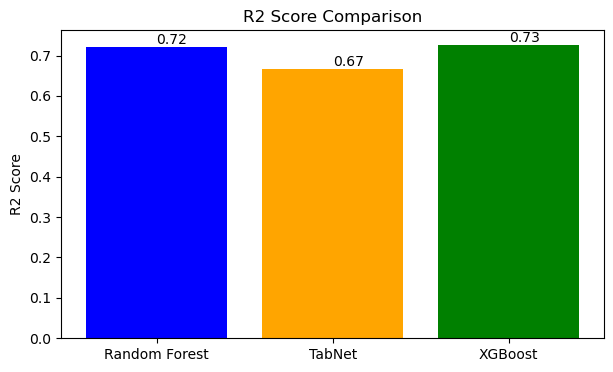

In [12]:
# Improvement Diagram
plt.figure(figsize=(7,4))
models = ['Random Forest', 'TabNet', 'XGBoost']
scores = [rf_r2, test_r2, xgb_r2]
bars = plt.bar(models, scores, color=['blue', 'orange', 'green'])
plt.title("R2 Score Comparison")
plt.ylabel("R2 Score")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom')
plt.show()

## SHAP: Random Forest

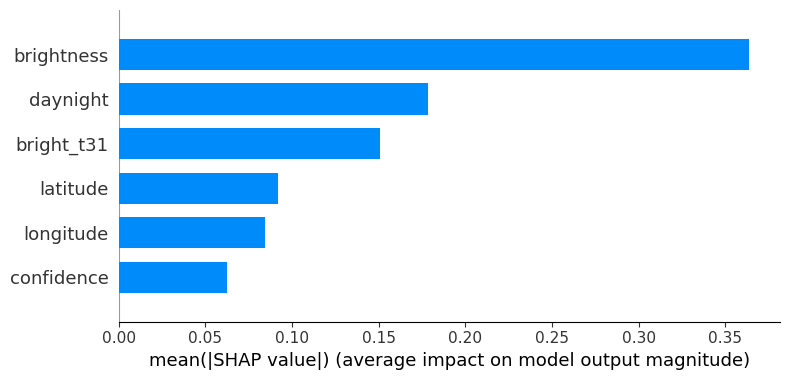

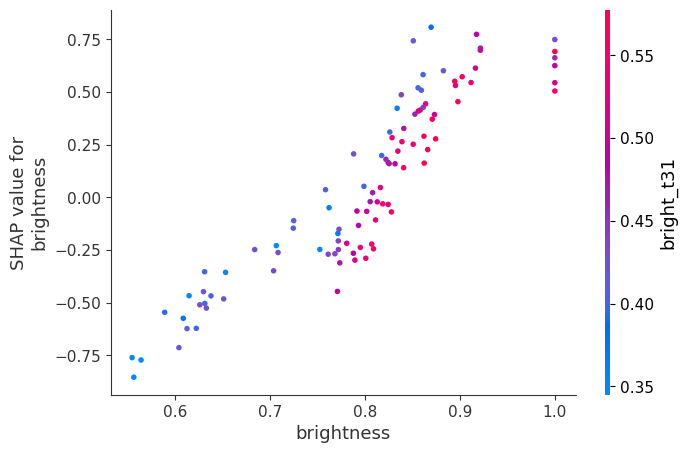

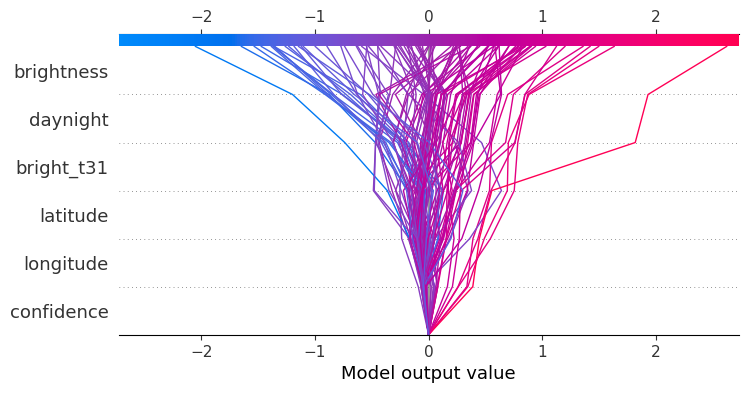

None

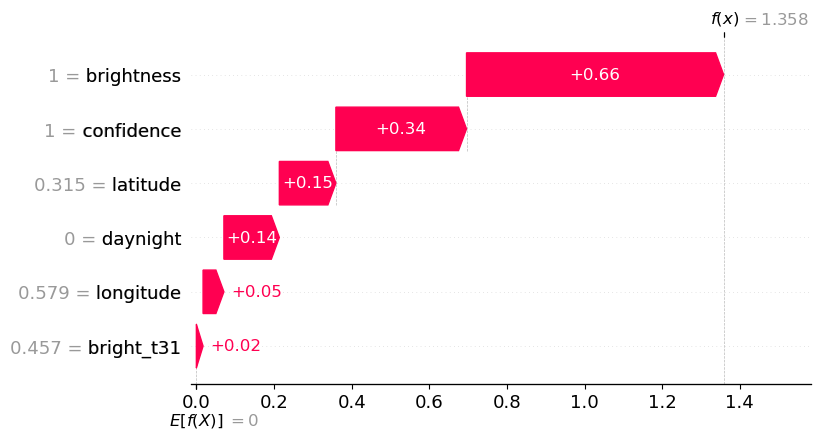

In [13]:
best_rf = rf_search.best_estimator_
X_sample = X_test.sample(n=100, random_state=42)

# Use TreeExplainer for efficiency with tree-based models
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_sample)

# Summary plot for feature importance
shap.summary_plot(shap_values, X_sample, plot_type="bar")
# Dependence plot for a key feature
shap.dependence_plot("brightness", shap_values, X_sample)

# Pick a single instance from the sample
instance = X_sample.iloc[[0]]
shap_values_instance = explainer.shap_values(instance)
# Generate a decision plot
display(shap.decision_plot(explainer.expected_value, shap_values, X_sample))

# Generate an Explanation object and plot a waterfall for one instance
explanation = explainer(X_sample)
single_explanation = explanation[0]
shap.plots.waterfall(single_explanation, max_display=10, show=True)

## SHAP: TabNet

  0%|          | 0/100 [00:00<?, ?it/s]

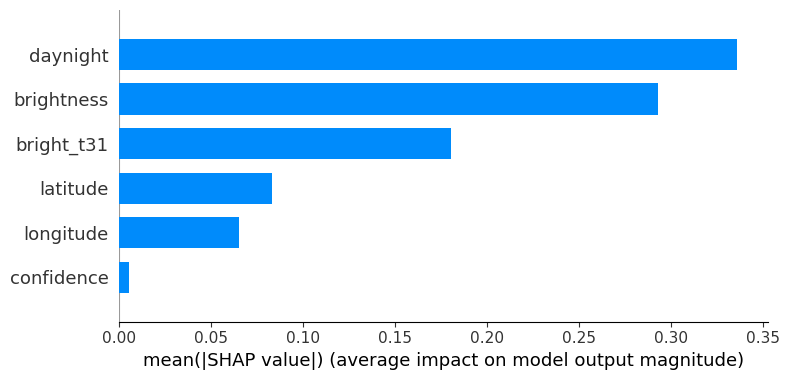

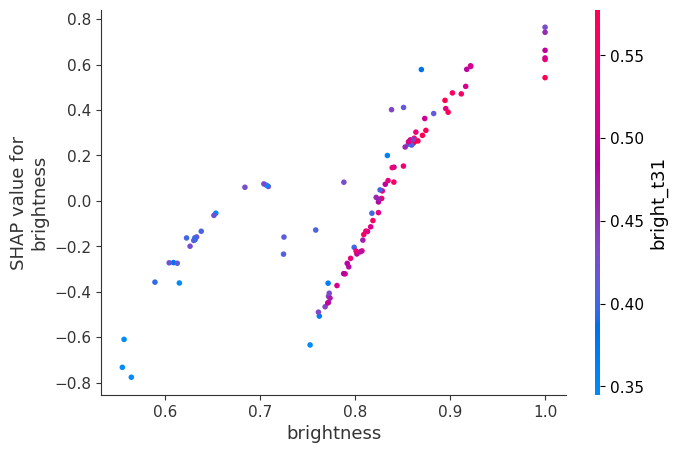

  0%|          | 0/1 [00:00<?, ?it/s]

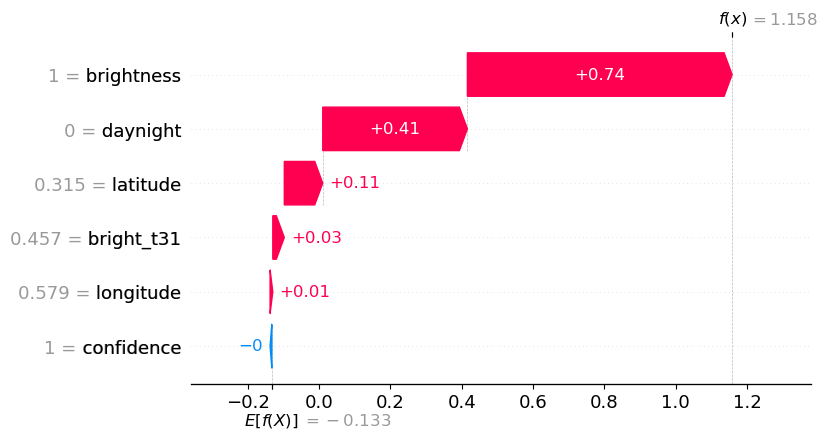

In [14]:
features = FEATURES

X_test_tab_df = pd.DataFrame(X_test_tab, columns=features)
X_train_tab_df = pd.DataFrame(X_train_tab, columns=features)

X_sample_df = X_test_tab_df.sample(n=100, random_state=42)
X_background_df = X_train_tab_df.sample(n=50, random_state=42)

def tabnet_predict(data):
    return best_model.predict(data).ravel()

# KernelExplainer since TabNet doesn't expose gradients the way tree models do
explainer = shap.KernelExplainer(tabnet_predict, X_background_df)
shap_values = explainer.shap_values(X_sample_df)

shap.summary_plot(shap_values, X_sample_df, plot_type="bar")
shap.dependence_plot("brightness", shap_values, X_sample_df)

instance = X_sample_df.iloc[[0]]
shap_values_instance = explainer.shap_values(instance)

explanation_instance = shap.Explanation(
    values=shap_values_instance,
    base_values=explainer.expected_value,
    data=instance
)
shap.plots.waterfall(explanation_instance[0], max_display=10, show=True)

## SHAP: XGBoost

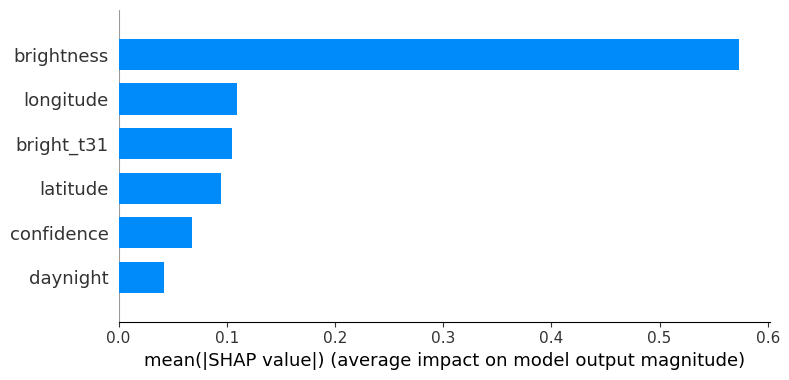

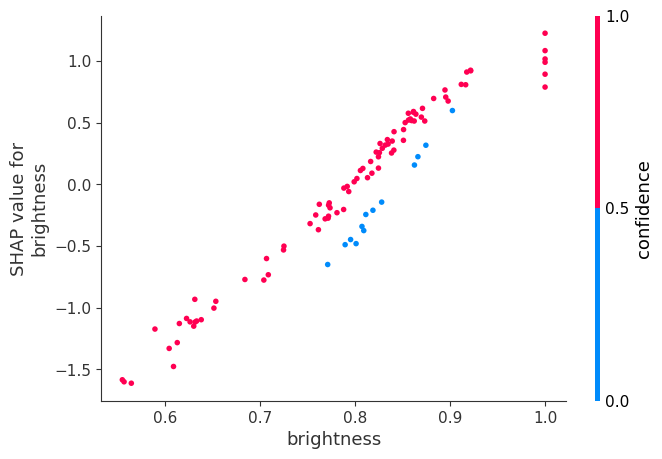

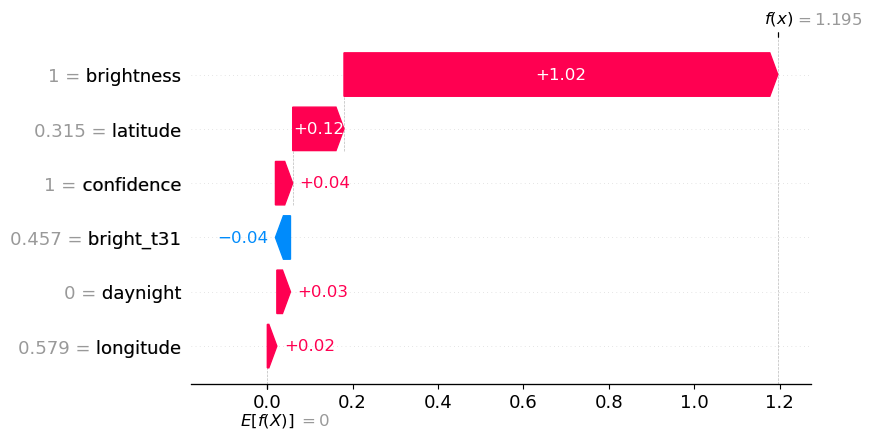

In [15]:
best_xgb = xgb_search.best_estimator_
X_sample_xgb = X_test.sample(n=100, random_state=42)

# TreeExplainer works directly on XGBoost too -- exact and fast
explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_sample_xgb)

shap.summary_plot(shap_values_xgb, X_sample_xgb, plot_type="bar")
shap.dependence_plot("brightness", shap_values_xgb, X_sample_xgb)

explanation_xgb = explainer_xgb(X_sample_xgb)
shap.plots.waterfall(explanation_xgb[0], max_display=10, show=True)